# Model results for all cantons

## Initial configuration

In [1]:
import pandas as pd
import sys
import numpy as np

sys.path.append('../../models')

from model_rr import Model

In [2]:
df = pd.read_csv('../../data/clean/full_data.csv')

In [3]:
cantons = [101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 201, -202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 301, 302, 303, 304, 305, 306, 307, 308, 401, 402, 403, 404, 405, 406, 407, 408, 409, 410, 501, 502, 503, 504, 505, 506, 507, 508, 509, 510, 511, 601, 602, 603, 604, 605, 606, 607, 608, 609, 610, 611, 701, 702, 703, 704, 705, 706]

cantons = [str(x) for x in cantons]

# Preparing the data

In [4]:
instancia = Model(df, "full")
X_combined, y_combined, X_train, X_test, y_test, test, pds, epsilon = instancia.partition()

# Random Forest

## Fitting the model

In [5]:
instancia.rf_reg(X_combined, y_combined, X_test, y_test, test, pds, epsilon)

RF Model Ready for full


## Calculate NRMSE

In [6]:
cod_cant_rf, nrmse_rf = instancia.calculate_nrmse("rf", epsilon)
round(nrmse_rf, 4)

np.float64(1.6705)

In [7]:
instancia.confint_nrmse("rf", X_combined, y_combined, X_test, y_test, epsilon, n_bootstraps = 50)

point estimate: 1.68
lower bound: 1.66, upper bound: 1.7


### Feature importance

              Feature    imp_rf    std_rf
0            rr_lag_1  0.211730  0.009855
1            rr_lag_2  0.116648  0.007962
2            rr_lag_4  0.025929  0.004896
3            rr_lag_3  0.021508  0.004766
4    precip_max_lag_3  0.001053  0.000572
..                ...       ...       ...
103   tmax_mean_lag_4 -0.002246  0.000567
104   tmax_mean_lag_1 -0.002759  0.000706
105   temp_prom_lag_1 -0.002789  0.000561
106   tmin_mean_lag_4 -0.003484  0.000790
107   temp_prom_lag_3 -0.005130  0.000550

[108 rows x 3 columns]


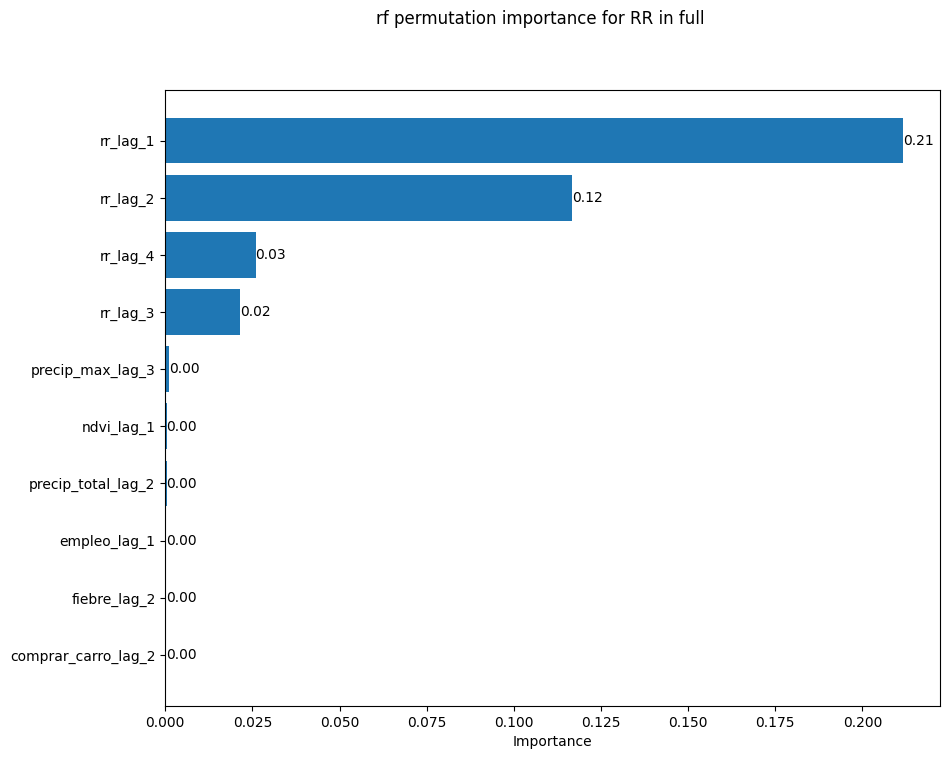

,Feature,imp_rf,std_rf
0,rr_lag_1,0.211730,0.009855
1,rr_lag_2,0.116648,0.007962
2,rr_lag_4,0.025929,0.004896
3,rr_lag_3,0.021508,0.004766
4,precip_max_lag_3,0.001053,0.000572
...,...,...,...
103,tmax_mean_lag_4,-0.002246,0.000567
104,tmax_mean_lag_1,-0.002759,0.000706
105,temp_prom_lag_1,-0.002789,0.000561
106,tmin_mean_lag_4,-0.003484,0.000790


In [8]:
instancia.var_importance(X_combined, y_combined, X_test, y_test, "rf", epsilon, repeats = 50, var = "RR")

### Feature selection

Optimal number of features for RR and rf: 6
Selected features: ['rr_lag_4', 'rr_lag_3', 'rr_lag_2', 'rr_lag_1', 'tmin_mean_lag_4', 'nino34ssta_lag_4']


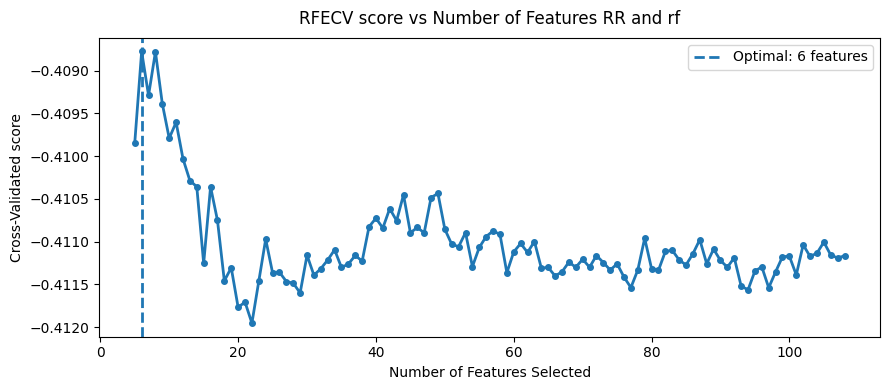

New NRMSE with selected features: 1.6623


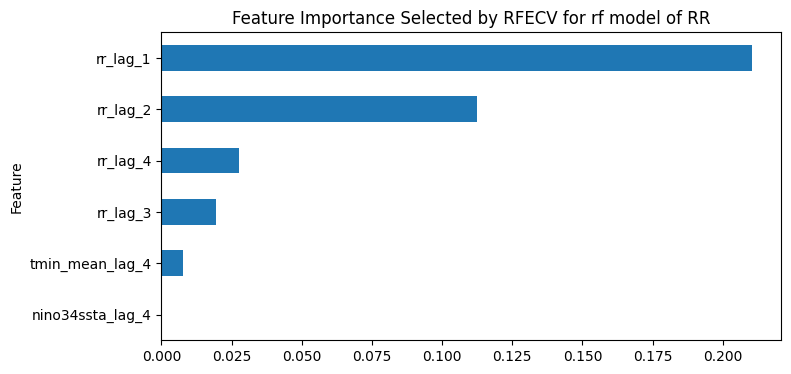

In [5]:
instancia.rfecv_selection("rf", X_combined, y_combined, X_test, y_test, pds, epsilon, repeats = 50, var = "RR")

# XGB

## Fit model

In [10]:
instancia.xgb_reg(X_combined, y_combined, X_test, y_test, test, pds, epsilon)

XGB Model Ready for full


## Calculate NRMSE

In [11]:
cod_cant_xgb, nrmse_xgb = instancia.calculate_nrmse("xgb", epsilon)

nrmse_xgb 

np.float64(1.6615869468430067)

In [12]:
instancia.confint_nrmse("xgb", X_combined, y_combined, X_test, y_test, epsilon, n_bootstraps = 50)

point estimate: 1.67
lower bound: 1.65, upper bound: 1.69


### Feature importance

                 Feature   imp_xgb   std_xgb
0               rr_lag_1  0.227821  0.009533
1               rr_lag_2  0.085183  0.006855
2               rr_lag_4  0.028720  0.004676
3               rr_lag_3  0.026161  0.004568
4     precip_total_lag_2  0.000657  0.000373
..                   ...       ...       ...
103      temp_prom_lag_4 -0.000229  0.000300
104      tmin_mean_lag_1 -0.000238  0.000182
105     precip_max_lag_4 -0.000252  0.000183
106  precip_median_lag_3 -0.000292  0.000181
107      tmax_mean_lag_3 -0.000608  0.000578

[108 rows x 3 columns]


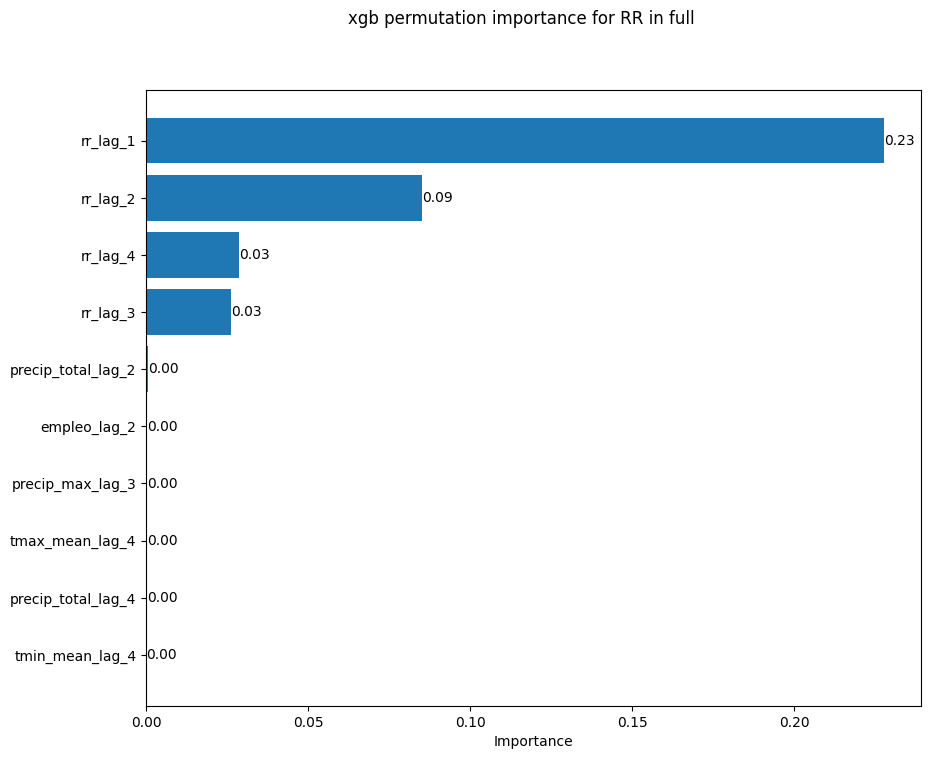

,Feature,imp_xgb,std_xgb
0,rr_lag_1,0.227821,0.009533
1,rr_lag_2,0.085183,0.006855
2,rr_lag_4,0.028720,0.004676
3,rr_lag_3,0.026161,0.004568
4,precip_total_lag_2,0.000657,0.000373
...,...,...,...
103,temp_prom_lag_4,-0.000229,0.000300
104,tmin_mean_lag_1,-0.000238,0.000182
105,precip_max_lag_4,-0.000252,0.000183
106,precip_median_lag_3,-0.000292,0.000181


In [13]:
instancia.var_importance(X_combined, y_combined, X_test, y_test, "xgb", epsilon, repeats = 50, var = "RR")

### Feature selection

Optimal number of features for RR and xgb: 48
Selected features: ['nino34ssta', 'rr_lag_4', 'rr_lag_3', 'rr_lag_2', 'rr_lag_1', 'ndvi_lag_4', 'ndvi_lag_3', 'ndvi_lag_2', 'ndvi_lag_1', 'tmax_mean_lag_4', 'tmax_mean_lag_3', 'tmax_mean_lag_2', 'tmax_mean_lag_1', 'tmin_mean_lag_4', 'tmin_mean_lag_3', 'tmin_mean_lag_2', 'tmin_mean_lag_1', 'nino34ssta_lag_4', 'nino34ssta_lag_3', 'nino34ssta_lag_2', 'temp_prom_lag_4', 'temp_prom_lag_3', 'temp_prom_lag_2', 'fiebre_lag_1', 'desempleo_lag_2', 'empleo_lag_4', 'empleo_lag_3', 'empleo_lag_2', 'empleo_lag_1', 'tiquetes_avion_lag_4', 'vacaciones_lag_4', 'vacaciones_lag_2', 'vacaciones_lag_1', 'corte_agua_lag_3', 'corte_de_agua_lag_3', 'corte_de_agua_lag_2', 'corte_de_agua_lag_1', 'dengue_lag_4', 'dengue_lag_1', 'precip_total_lag_4', 'precip_total_lag_3', 'precip_total_lag_2', 'precip_max_lag_4', 'precip_max_lag_3', 'precip_max_lag_2', 'precip_max_lag_1', 'precip_median_lag_3', 'precip_median_lag_1']


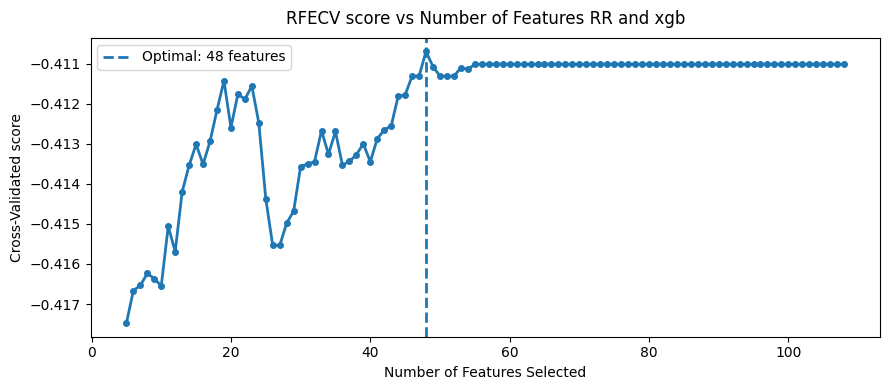

New NRMSE with selected features: 1.6620


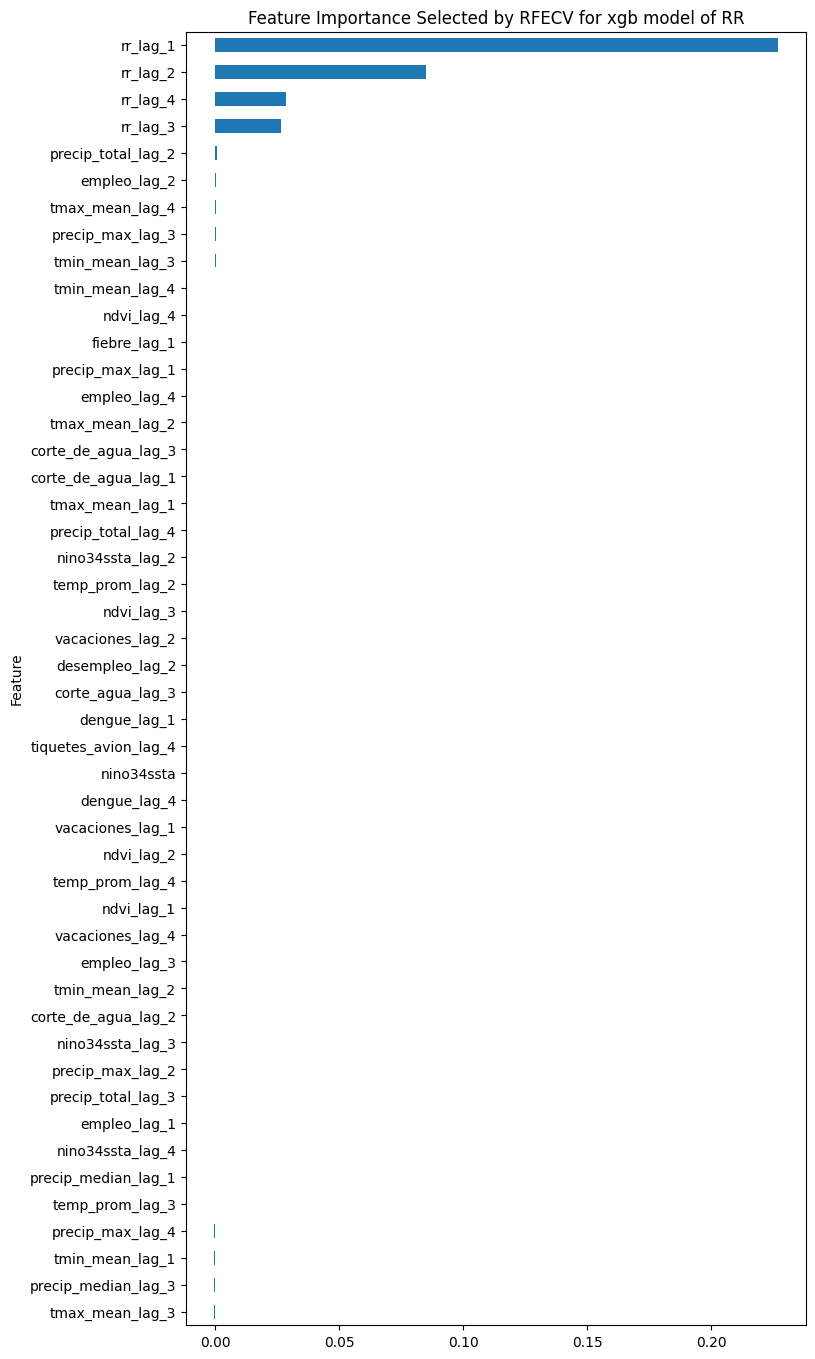

In [6]:
instancia.rfecv_selection("xgb", X_combined, y_combined, X_test, y_test, pds, epsilon, repeats = 50, var = "RR")

# HRF

## Fit models

In [6]:
best_th_hrf = instancia.hybrid("hrf", X_combined, y_combined, X_train, X_test, y_test, test, pds, epsilon)

Using PredefinedSplit: n_train=5530, n_val=2854
hrf ready for full


In [11]:
best_th_hrf_df = pd.DataFrame({"canton": ["full"], "best_th": [best_th_hrf]})

best_th_hrf_df.to_csv("../../data/model_results/thresholds/full_threshold_hrf.csv", index = False)

In [8]:
best_th_hrf

0.36

## Calculate NRMSE

In [12]:
cod_cant_hrf, nrmse_hrf = instancia.calculate_nrmse("hrf", epsilon)

nrmse_hrf 

np.float64(1.6910371212654667)

In [14]:
instancia.confint_nrmse("hrf", X_combined, y_combined, X_test, y_test, epsilon, n_bootstraps = 50)

point estimate: 1.71
lower bound: 1.69, upper bound: 1.73


### Feature importance

                 Feature   imp_hrf   std_hrf
0               rr_lag_1  0.602846  0.028684
1               rr_lag_4  0.230155  0.021869
2               rr_lag_2  0.143211  0.013356
3               rr_lag_3  0.039887  0.011077
4                  urb_1  0.011094  0.002002
..                   ...       ...       ...
103    precip_mean_lag_1 -0.001784  0.000631
104     nino34ssta_lag_3 -0.003620  0.001186
105  precip_median_lag_2 -0.003649  0.001234
106     nino34ssta_lag_2 -0.004486  0.001031
107     nino34ssta_lag_4 -0.005782  0.001851

[108 rows x 3 columns]


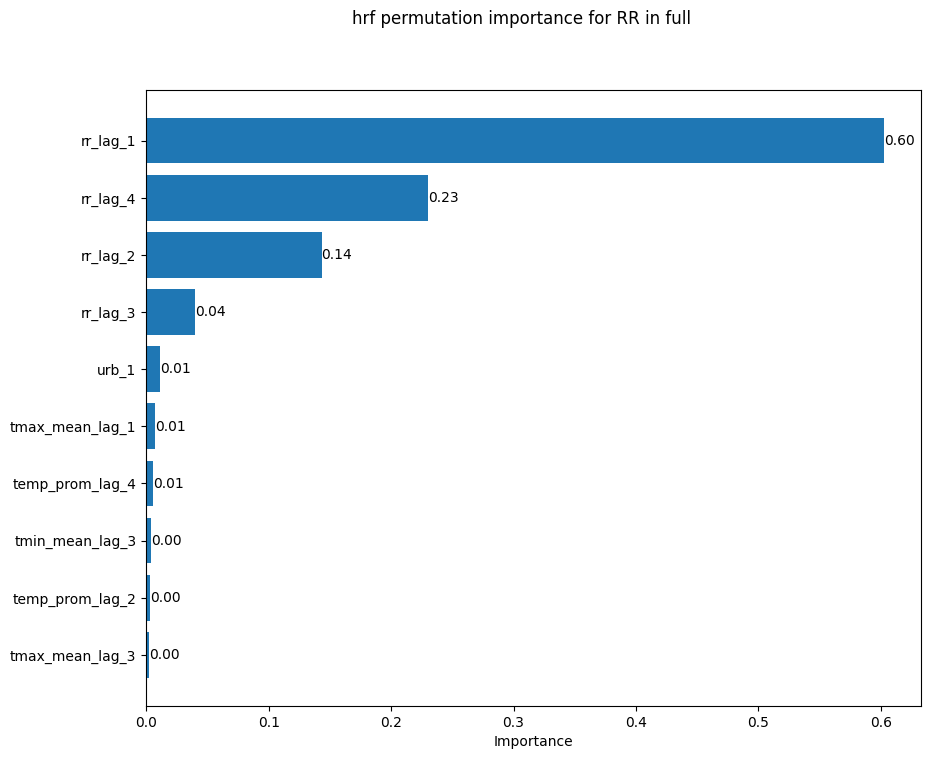

,Feature,imp_hrf,std_hrf
0,rr_lag_1,0.602846,0.028684
1,rr_lag_4,0.230155,0.021869
2,rr_lag_2,0.143211,0.013356
3,rr_lag_3,0.039887,0.011077
4,urb_1,0.011094,0.002002
...,...,...,...
103,precip_mean_lag_1,-0.001784,0.000631
104,nino34ssta_lag_3,-0.003620,0.001186
105,precip_median_lag_2,-0.003649,0.001234
106,nino34ssta_lag_2,-0.004486,0.001031


In [15]:
instancia.var_importance(X_combined, y_combined, X_test, y_test, "hrf", epsilon, repeats = 50, var = "RR")

### Feature selection

Optimal number of features for RR and hrf: 5
Selected features: ['rr_lag_4', 'rr_lag_3', 'rr_lag_2', 'rr_lag_1', 'nino34ssta_lag_4']


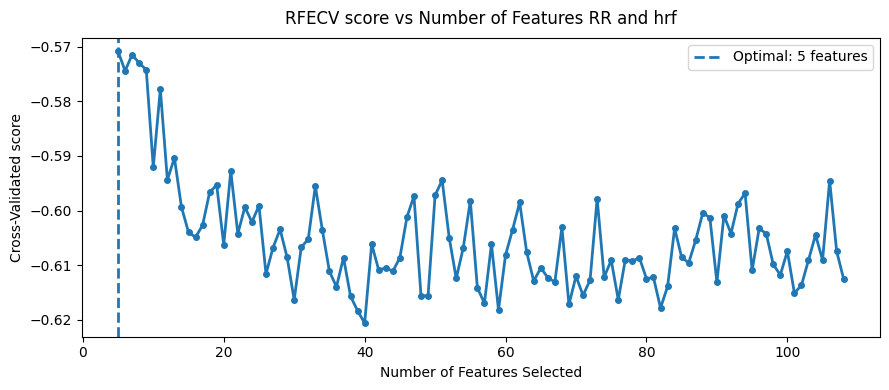

New NRMSE with selected features: 1.7038


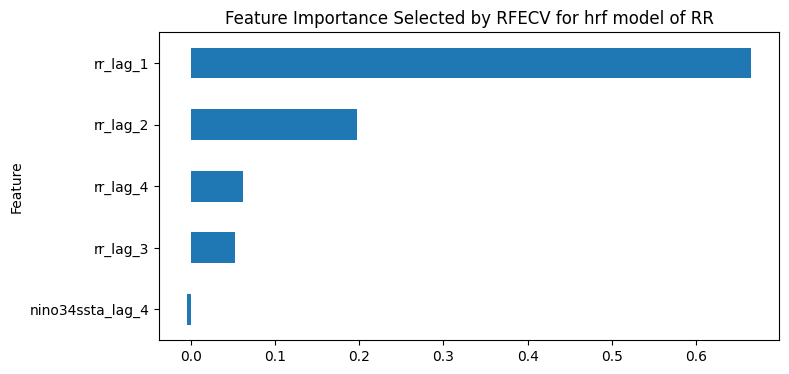

In [7]:
instancia.rfecv_selection("hrf", X_combined, y_combined, X_test, y_test, pds, epsilon, repeats = 50, var = "RR")

# HXGB

## Fit model

In [10]:
best_th_hxgb = instancia.hybrid("hxgb", X_combined, y_combined, X_train, X_test, y_test, test, pds, epsilon)

Using PredefinedSplit: n_train=5530, n_val=2854
hxgb ready for full


In [11]:
best_th_hxgb_df = pd.DataFrame({"canton": ["full"], "best_th": [best_th_hxgb]})

best_th_hxgb_df.to_csv("../../data/model_results/thresholds/full_threshold_hxgb.csv", index = False)

In [12]:
best_th_hxgb

0.4

## Calculate NRMSE

In [13]:
cod_cant_hxgb, nrmse_hxgb = instancia.calculate_nrmse("hxgb", epsilon)

nrmse_hxgb 

np.float64(1.7193563156792695)

In [17]:
instancia.confint_nrmse("hxgb", X_combined, y_combined, X_test, y_test, epsilon, n_bootstraps = 50)

point estimate: 1.7
lower bound: 1.67, upper bound: 1.73


### Feature importance

              Feature  imp_hxgb  std_hxgb
0            rr_lag_1  0.353543  0.028265
1            rr_lag_2  0.100000  0.017442
2            rr_lag_3  0.049280  0.015371
3            rr_lag_4  0.041504  0.016048
4               urb_1  0.006970  0.001338
..                ...       ...       ...
103   tmax_mean_lag_3 -0.006692  0.001657
104   temp_prom_lag_3 -0.012137  0.006765
105   tmin_mean_lag_4 -0.014399  0.006750
106   temp_prom_lag_4 -0.015930  0.010425
107  nino34ssta_lag_4 -0.044086  0.015335

[108 rows x 3 columns]


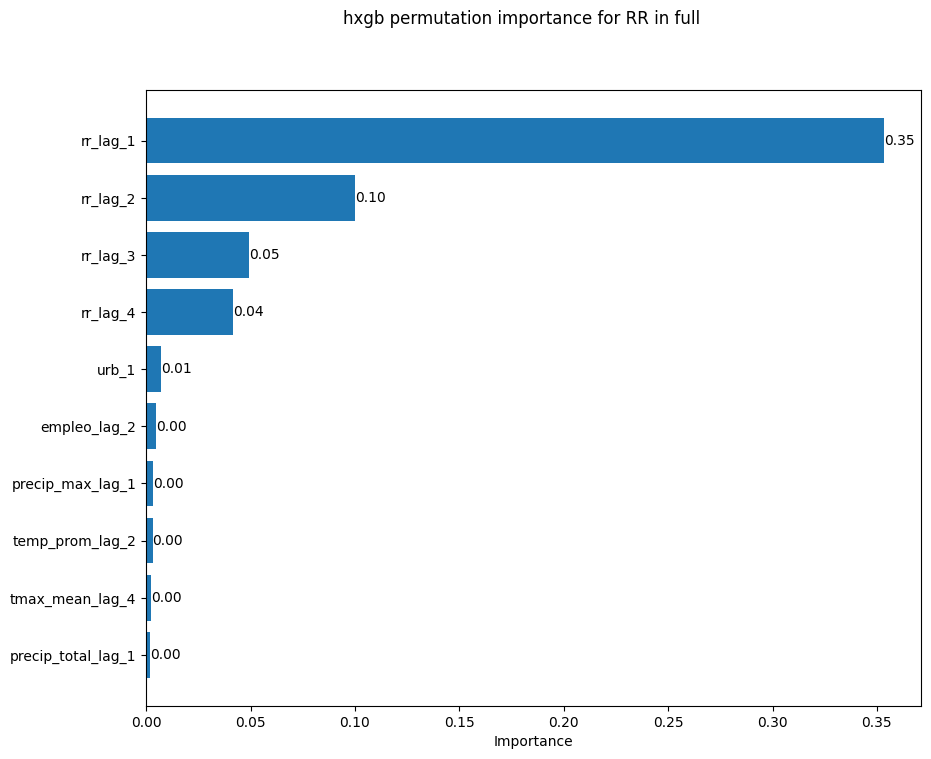

,Feature,imp_hxgb,std_hxgb
0,rr_lag_1,0.353543,0.028265
1,rr_lag_2,0.100000,0.017442
2,rr_lag_3,0.049280,0.015371
3,rr_lag_4,0.041504,0.016048
4,urb_1,0.006970,0.001338
...,...,...,...
103,tmax_mean_lag_3,-0.006692,0.001657
104,temp_prom_lag_3,-0.012137,0.006765
105,tmin_mean_lag_4,-0.014399,0.006750
106,temp_prom_lag_4,-0.015930,0.010425


In [18]:
instancia.var_importance(X_combined, y_combined, X_test, y_test, "hxgb", epsilon, repeats = 50, var = "RR")

### Feature selection

Optimal number of features for RR and hxgb: 10
Selected features: ['rr_lag_4', 'rr_lag_3', 'rr_lag_2', 'rr_lag_1', 'nino34ssta_lag_4', 'nino34ssta_lag_3', 'nino34ssta_lag_2', 'nino34ssta_lag_1', 'precip_median_lag_3', 'urb_1']


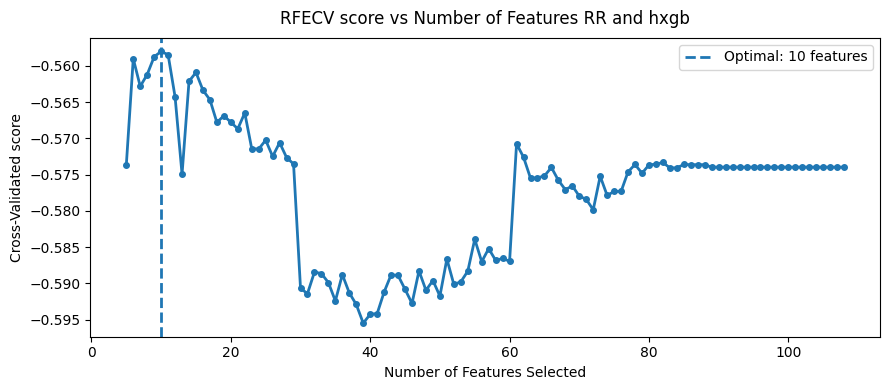

New NRMSE with selected features: 1.7022


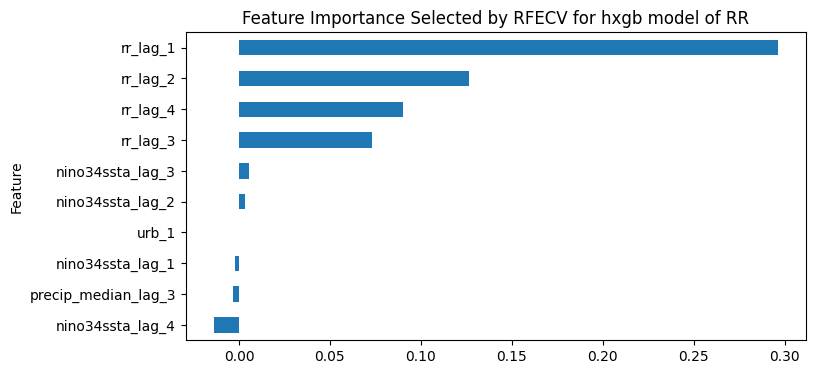

In [8]:
instancia.rfecv_selection("hxgb", X_combined, y_combined, X_test, y_test, pds, epsilon, repeats = 50, var = "RR")